<a href="https://colab.research.google.com/github/MishaE-e/ml_fmi/blob/main/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Набор данных: https://archive.ics.uci.edu/dataset/837/product+classification+and+clustering

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

2. Загрузка данных

In [25]:
df = pd.read_csv(u'pricerunner_aggregate.csv')

In [26]:
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges


In [27]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Найдено категориальных столбцов: {len(categorical_cols)}")
print(f"Список: {list(categorical_cols)}")

Найдено категориальных столбцов: 3
Список: ['Product Title', ' Cluster Label', ' Category Label']


In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
df_new = df.drop([' Cluster Label', 'Product Title'], axis=1)

In [30]:
df_new

,Product ID,Merchant ID,Cluster ID,Category ID,Category Label
0,1,1,1,2612,Mobile Phones
1,2,2,1,2612,Mobile Phones
2,3,3,1,2612,Mobile Phones
3,4,4,1,2612,Mobile Phones
4,5,5,1,2612,Mobile Phones
...,...,...,...,...,...
35306,47350,59,47517,2623,Fridges
35307,47351,59,47518,2623,Fridges
35308,47352,59,47519,2623,Fridges
35309,47355,125,47524,2623,Fridges


3. Краткая информация

In [31]:
print("Краткая информация:")
df.info()
print(f"\nРазмерность: {df.shape}")
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")
print(f"\nПропусков по столбцам:\n{df.isnull().sum()}")
print(f"\nКоличество дубликатов: {df.duplicated().sum()}")
print(f"\nCтатистическая информация:\n{df.describe()}")

Краткая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product ID       35311 non-null  int64 
 1   Product Title    35311 non-null  object
 2    Merchant ID     35311 non-null  int64 
 3    Cluster ID      35311 non-null  int64 
 4    Cluster Label   35311 non-null  object
 5    Category ID     35311 non-null  int64 
 6    Category Label  35311 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.9+ MB

Размерность: (35311, 7)

Всего пропусков: 0

Пропусков по столбцам:
Product ID         0
Product Title      0
 Merchant ID       0
 Cluster ID        0
 Cluster Label     0
 Category ID       0
 Category Label    0
dtype: int64

Количество дубликатов: 0

Cтатистическая информация:
         Product ID   Merchant ID    Cluster ID   Category ID
count  35311.000000  35311.000000  35311.000000  35311.000000
mean   261

In [32]:
df_new[' Category Label'].unique()

array(['Mobile Phones', 'TVs', 'CPUs', 'Digital Cameras', 'Microwaves',
       'Dishwashers', 'Washing Machines', 'Freezers', 'Fridge Freezers',
       'Fridges'], dtype=object)

In [33]:
df_new[' Category Label'].value_counts()

,count
Category Label,
Fridge Freezers,5501
Mobile Phones,4081
Washing Machines,4044
CPUs,3862
Fridges,3584
TVs,3564
Dishwashers,3424
Digital Cameras,2697
Microwaves,2342


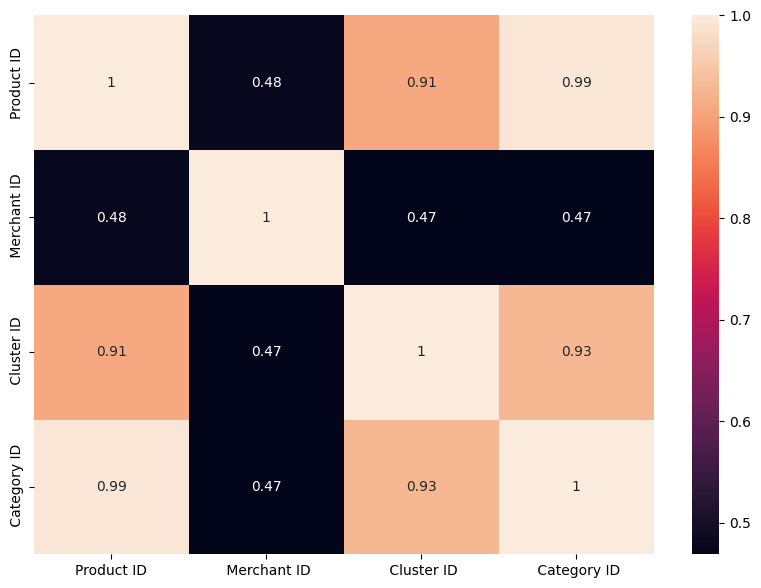

In [34]:
plt.figure(figsize = (10,7))
sns.heatmap(df.corr(numeric_only = True), annot=True)
plt.show()

Text(0.5, 1.0, 'Распределение целевой переменной')

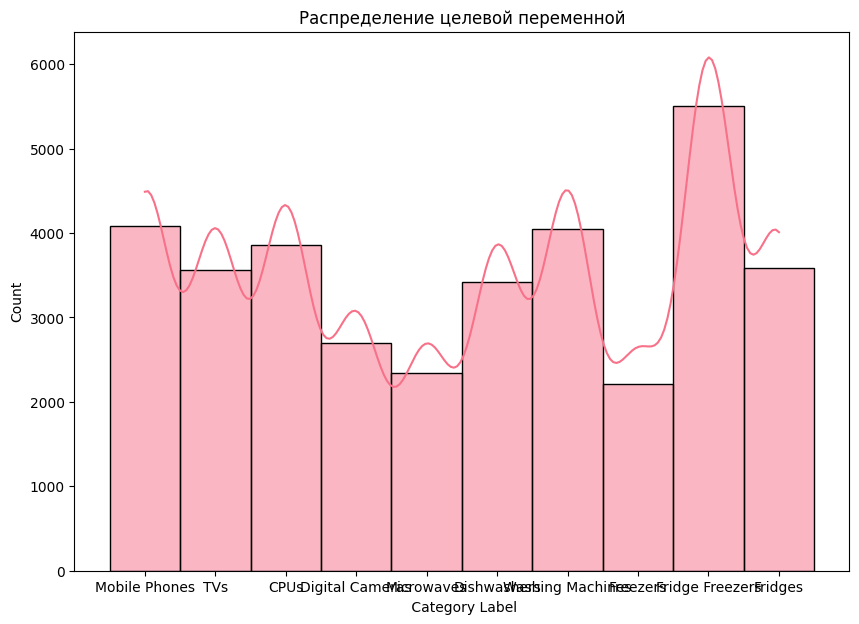

In [35]:
plt.figure(figsize=(10, 7))

sns.histplot(df[' Category Label'], kde=True)
plt.title('Распределение целевой переменной')

In [36]:
df_new[' Category Label'] = LabelEncoder().fit_transform(df_new[' Category Label'])

3. Предобработка

Y - целевая переменная, нашем случае это столбец Category Label.

В X складываем весь набор данных без целевой переменной.

In [37]:
X = df_new.drop([' Category Label'], axis = 1)
y = df_new[' Category Label']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (35311, 4) | y shape: (35311,) 


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 10)

4. Модели регрессии и метрики

In [39]:
#Функция для оценки моделей
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)

    print(f"\n{model_name}:")
    print(f"  R² на train: {train_r2:.4f}")
    print(f"  R² на test: {test_r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")

    return test_r2, y_test_pred

#Словарь для хранения результатов
results = {}
predictions = {}

#Линейная регрессия
lr = LinearRegression()
results['Linear Regression'], predictions['Linear Regression'] = evaluate_model(
    lr, X_train, y_train, X_test, y_test, "Линейная регрессия")

#Полиномиальная регрессия
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
results['Polynomial Regression'], predictions['Polynomial Regression'] = evaluate_model(
    lr_poly, X_train_poly, y_train, X_test_poly, y_test, "Полиномиальная регрессия")

#Ridge регрессия
ridge = Ridge(alpha=1.0)
results['Ridge'], predictions['Ridge'] = evaluate_model(
    ridge, X_train, y_train, X_test, y_test, "Ridge регрессия")

#SVR
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
results['SVR (rbf)'], predictions['SVR (rbf)'] = evaluate_model(
    svr_rbf, X_train, y_train, X_test, y_test, "SVR")


Линейная регрессия:
  R² на train: 0.0440
  R² на test: 0.0408
  MSE: 8.0767
  MAE: 2.4305

Полиномиальная регрессия:
  R² на train: 0.4367
  R² на test: 0.4448
  MSE: 4.6746
  MAE: 1.8685

Ridge регрессия:
  R² на train: 0.0440
  R² на test: 0.0408
  MSE: 8.0766
  MAE: 2.4305

SVR:
  R² на train: 0.9988
  R² на test: 0.4404
  MSE: 4.7122
  MAE: 1.6799
